In [37]:
import random
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

from pathlib import Path


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from components.models import ANFISAdvanced, fcm_initialize

In [38]:
# ---------------------------
# 1) Preparing the data
# ---------------------------

X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.int64)     # labels 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [39]:
# ---------------------------
# 5) Training (Classification)
# ---------------------------

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert labels to float for BCE
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

X_train_tensor = torch.from_numpy(X_train).to(device)
X_test_tensor  = torch.from_numpy(X_test).to(device)

# initialization
K = 3
centers_init, spreads_init = fcm_initialize(X_train, K)

# Model setup
s_mode_choice = "alpha_beta"   # or "C"
model = ANFISAdvanced(centers_init, spreads_init, s_mode=s_mode_choice).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Loss on raw logits
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 1000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward
    y_pred_train = model(X_train_tensor)

    # Loss
    loss = loss_fn(y_pred_train, y_train_tensor)

    # Backprop
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # Track best model
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Progress logging
    if epoch % 100 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_logits = model(X_train_tensor)
            test_logits  = model(X_test_tensor)
            train_prob = torch.sigmoid(train_logits)
            test_prob  = torch.sigmoid(test_logits)

            train_pred = (train_prob >= 0.5).float()
            test_pred = (test_prob >= 0.5).float()

            train_total = y_train_tensor.numel()
            test_total = y_test_tensor.numel()
            train_correct = int((train_pred == y_train_tensor).sum().item())
            test_correct = int((test_pred == y_test_tensor).sum().item())
            train_acc = train_correct / train_total
            test_acc = test_correct / test_total
            train_err = 1.0 - train_acc
            test_err = 1.0 - test_acc

        print(
            f"Epoch {epoch}/{n_epochs}  Loss: {loss.item():.4f}  "
            f"Train Acc: {train_acc:.3f} (Err {train_err:.3f})  "
            f"Test Acc: {test_acc:.3f} (Err {test_err:.3f})"
        )

# Restore best parameters
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()


# ---------------------------
# 6) Final Evaluation
# ---------------------------
with torch.no_grad():
    final_train_prob = torch.sigmoid(model(X_train_tensor)).cpu().numpy().reshape(-1)
    final_test_prob  = torch.sigmoid(model(X_test_tensor)).cpu().numpy().reshape(-1)


def summarize_split(name, probs, labels):
    preds = (probs >= 0.5).astype(np.int64)
    total = len(labels)
    correct = int((preds == labels).sum())
    wrong = total - correct
    accuracy = correct / total
    error = wrong / total
    print(
        f"{name}: accuracy rate {accuracy:.3f} ({correct}/{total} correct points) | "
        f"error {error:.3f} ({wrong} wrong points)"
    )


print("\nFinal Results:")
print("Mode:", s_mode_choice)
summarize_split("Train", final_train_prob, y_train)
summarize_split("Test", final_test_prob, y_test)


Epoch 1/1000  Loss: 0.6888  Train Acc: 0.502 (Err 0.498)  Test Acc: 0.492 (Err 0.508)
Epoch 100/1000  Loss: 0.6337  Train Acc: 0.808 (Err 0.192)  Test Acc: 0.820 (Err 0.180)
Epoch 200/1000  Loss: 0.5812  Train Acc: 0.812 (Err 0.188)  Test Acc: 0.825 (Err 0.175)
Epoch 300/1000  Loss: 0.5269  Train Acc: 0.834 (Err 0.166)  Test Acc: 0.838 (Err 0.162)
Epoch 400/1000  Loss: 0.4728  Train Acc: 0.852 (Err 0.148)  Test Acc: 0.863 (Err 0.137)
Epoch 500/1000  Loss: 0.4270  Train Acc: 0.863 (Err 0.137)  Test Acc: 0.863 (Err 0.137)
Epoch 600/1000  Loss: 0.3903  Train Acc: 0.871 (Err 0.129)  Test Acc: 0.882 (Err 0.118)
Epoch 700/1000  Loss: 0.3553  Train Acc: 0.882 (Err 0.118)  Test Acc: 0.895 (Err 0.105)
Epoch 800/1000  Loss: 0.3167  Train Acc: 0.902 (Err 0.098)  Test Acc: 0.902 (Err 0.098)
Epoch 900/1000  Loss: 0.2752  Train Acc: 0.922 (Err 0.078)  Test Acc: 0.915 (Err 0.085)
Epoch 1000/1000  Loss: 0.2359  Train Acc: 0.945 (Err 0.055)  Test Acc: 0.940 (Err 0.060)

Final Results:
Mode: alpha_beta


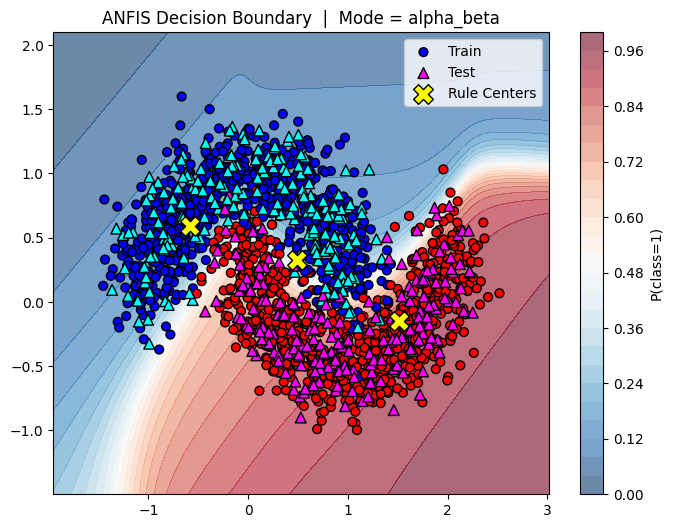

In [40]:
# ---------------------------
# 7: Plot decision boundary
# ---------------------------
plt.figure(figsize=(8, 6))

# Grid for visualization
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_tensor = torch.from_numpy(grid).to(device)

with torch.no_grad():
    prob_grid = torch.sigmoid(model(grid_tensor)).cpu().numpy().reshape(xx.shape)

# Decision boundary contour
contour = plt.contourf(xx, yy, prob_grid, levels=30, cmap="RdBu_r", alpha=0.6)
plt.colorbar(contour, label="P(class=1)")

# Training data
plt.scatter(
    X_train[:, 0], X_train[:, 1], 
    c=y_train, cmap="bwr", edgecolor="k", s=40, label="Train"
)

# Test data
plt.scatter(
    X_test[:, 0], X_test[:, 1], 
    c=y_test, cmap="cool", edgecolor="k", s=60, marker="^", label="Test"
)

# Optional: show rule centers
plt.scatter(
    centers_init[:, 0], centers_init[:, 1],
    c="yellow", s=200, edgecolor="black", marker="X",
    label="Rule Centers"
)

plt.title(f"ANFIS Decision Boundary  |  Mode = {s_mode_choice}")
plt.legend()
plt.show()
